**Now working to extract the parameters of GaNs to help us analyse QDs and make height thresholding estimates**

Since this file is no longer connected to the others, we need to ensure that the connections betweem all of them is still working. But we are still uploading things form the Detection notebook so that we can keep working with the destriped image.

# Image Uploading and establishing connections between files and folders 

## Linking files

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()

while not (
    (PROJECT_ROOT / "Detection").exists()
    and (PROJECT_ROOT / "Image-Preprocessing").exists()
    and (PROJECT_ROOT / "Ground-Truth").exists()
    and (PROJECT_ROOT / "QD-Analysis").exists()
):
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find project root.")

    PROJECT_ROOT = PROJECT_ROOT.parent


DETECTION_DIR = PROJECT_ROOT / "Detection"
PREPROCESSING_DIR = PROJECT_ROOT / "Image-Preprocessing"
GROUND_TRUTH_DIR = PROJECT_ROOT / "Ground-Truth"
QD_ANALYSIS_DIR = PROJECT_ROOT / "QD-Analysis"

CLASSICAL_DIR = DETECTION_DIR / "Classical-Optimised"
BIOLOGY_DIR = DETECTION_DIR / "Biology-Inspired"
CNN_DIR = DETECTION_DIR / "Binary-CNN-Model"


for path in [
    PROJECT_ROOT,
    DETECTION_DIR,
    PREPROCESSING_DIR,
    GROUND_TRUTH_DIR,
    QD_ANALYSIS_DIR,
    CLASSICAL_DIR,
    BIOLOGY_DIR,
    CNN_DIR,
]:
    path_str = str(path)

    if path_str not in sys.path:
        sys.path.insert(0, path_str)

## Libraries and including files

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import basic_data_preprocessing as bdp
import foreground_preprocessing as fp
import preprocessing_metrics as pm

import detection_algorithms as da
import detection_errors as de

import QD_analysis as qa

In [3]:
from scipy.ndimage import uniform_filter

from skimage.filters import (threshold_otsu, threshold_sauvola, threshold_li, threshold_yen,)
from skimage.measure import label, regionprops
from skimage.morphology import (binary_closing, binary_dilation, disk, remove_small_objects,)

from __future__ import annotations

from scipy.ndimage import gaussian_filter
from scipy.ndimage import median_filter
from skimage import exposure

from skimage.feature import blob_log
from skimage.filters import gaussian
from skimage.restoration import denoise_tv_chambolle

from skimage.filters import sobel, threshold_otsu 
from skimage.morphology import remove_small_objects 

from scipy.ndimage import gaussian_laplace

from skimage.filters import threshold_multiotsu
from scipy.ndimage import gaussian_filter
from scipy.ndimage import median_filter
from skimage import exposure

from scipy.ndimage import binary_fill_holes, gaussian_filter
from skimage.feature import peak_local_max
from skimage.measure import label
from skimage.morphology import white_tophat, disk
from scipy.ndimage import gaussian_filter, median_filter

## Uploading the Scans

In [4]:
DATA_DIR = PROJECT_ROOT / "Data-Conversion"
GT_DATA_DIR = GROUND_TRUTH_DIR / "NPY-Ground-Truth"

SCAN_DIRS = {
    "Scan1": GT_DATA_DIR / "Scan1",
    "Scan2": GT_DATA_DIR / "Scan2",
    "Scan3": GT_DATA_DIR / "Scan3",
}

### Pre-processing Scans 

In [5]:
raw_scans = []
processed_scans = []
ground_truth_masks = []

for scan_name in ["Scan1", "Scan2", "Scan3"]:
    scan_dir = SCAN_DIRS[scan_name]

    raw = np.load(scan_dir / "channel_00___0_data.npy")

    mask = np.load(scan_dir / "channel_00___0_data_mask.npy")

    processed, stages = bdp.preprocess_afm(
        raw,
        remove_plane=True,
        line_flatten=True,
        align_rows=True,
        remove_2d_background=False,
    )

    raw_scans.append(raw)
    processed_scans.append(processed)
    ground_truth_masks.append(mask)

In [6]:
dataset = {}

for scan_name, raw, processed, mask in zip(
    ["Scan1", "Scan2", "Scan3"],
    raw_scans,
    processed_scans,
    ground_truth_masks,
):
    dataset[scan_name] = {
        "raw": raw,
        "processed": processed,
        "ground_truth_mask": mask,
        "ground_truth_centres": qa.centres_from_binary_mask(mask),
    }

Sanity-check (because sometimes notebooks kept forgetting about the variables..)

In [7]:
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Detection algorithms:", CLASSICAL_DIR.exists())
print("Preprocessing:", PREPROCESSING_DIR.exists())
print("Ground truth:", GROUND_TRUTH_DIR.exists())

print(dataset.keys())

for scan_name, data in dataset.items():
    print(
        scan_name,
        data["raw"].shape,
        data["ground_truth_mask"].shape,
        len(data["ground_truth_centres"]),
    )

PROJECT_ROOT: /Users/polinabobrova/Desktop/GaN Quantum Dot Analysis
Detection algorithms: True
Preprocessing: True
Ground truth: True
dict_keys(['Scan1', 'Scan2', 'Scan3'])
Scan1 (512, 512) (512, 512) 133
Scan2 (512, 512) (512, 512) 137
Scan3 (512, 512) (512, 512) 135


**Preprocess Scan 3:**

In [8]:
scan_name = "Scan3"
scan_dir = GROUND_TRUTH_DIR / "NPY-Ground-Truth" / scan_name

z = np.load(scan_dir / "channel_00___0_data.npy")
ground_truth_mask = np.load(scan_dir / "channel_00___0_data_mask.npy")

z_processed, stages = bdp.preprocess_afm(
    z,
    remove_plane=True,
    line_flatten=True,
    align_rows=True,
    remove_2d_background=False,
)

z_processed, stripe_map_2d = bdp.remove_partial_horizontal_stripes(
    z_processed,
    sigma_x=35,
    sigma_y_small=1.0,
    sigma_y_large=12.0,
    strength=0.75,
)

z_processed -= np.nanmedian(z_processed)

ground_truth_centres = qa.centres_from_binary_mask(ground_truth_mask)

# GaN layer detection

**Algorithm for GaN detection** 

1. Blur the background so that no small features get detected (gaussian smoothing with a high standard deviation)

2. Only allow features between 20-150 pixels to ramain and apply other thresholding techniques like:
    2.1 Otsu
    2.2 Sauvola
    2.3 Phansaulkar 
    2.4 Others?

3. Measure height at the different positions of the given blobs 

## 1. Heavy smoothing: suppress QDs and retain broad GaNs

In [9]:
GaN_sigma = 6

z_GaN_smooth = gaussian_filter(z_processed, sigma=GaN_sigma, mode="reflect",)
finite = np.isfinite(z_GaN_smooth)

# Normalize to [0, 1] for thresholding
z_min = np.nanmin(z_GaN_smooth)
z_max = np.nanmax(z_GaN_smooth)

z_GaN_norm = (z_GaN_smooth - z_min) / (z_max - z_min + 1e-12)

## 2. Threshold dark GaNs

Used different thresholding methods, after being inspired by ImageJ

In [10]:
# Global Otsu
otsu_threshold = threshold_otsu(z_GaN_norm[finite])
mask_otsu = (z_GaN_norm < otsu_threshold) & finite


# Local Sauvola
local_window = 51  # Must be odd
sauvola_threshold = threshold_sauvola(z_GaN_norm, window_size=local_window, k=0.15,)
mask_sauvola = (z_GaN_norm < sauvola_threshold) & finite


# Local Phansalkar
phansalkar_k = 0.25
phansalkar_r = 0.5
phansalkar_p = 2.0
phansalkar_q = 10.0

local_mean = uniform_filter(z_GaN_norm, size=local_window, mode="reflect",)
local_mean_squared = uniform_filter(z_GaN_norm**2, size=local_window, mode="reflect",)
local_std = np.sqrt(np.maximum(local_mean_squared - local_mean**2, 0,))

phansalkar_threshold = local_mean * (1 + phansalkar_p* np.exp(-phansalkar_q * local_mean)+ phansalkar_k* (local_std / phansalkar_r - 1))
mask_phansalkar = (z_GaN_norm < phansalkar_threshold) & finite


# Other global thresholds
li_threshold = threshold_li(z_GaN_norm[finite])
mask_li = (z_GaN_norm < li_threshold) & finite

yen_threshold = threshold_yen(z_GaN_norm[finite])
mask_yen = (z_GaN_norm < yen_threshold) & finite

**Keep objects within the required area range**

In [11]:
minimum_area = 8
maximum_area = 2500

raw_masks = {
    "Otsu": mask_otsu,
    "Sauvola": mask_sauvola,
    "Phansalkar": mask_phansalkar,
    "Li": mask_li,
    "Yen": mask_yen,
}

filtered_masks = {}

for name, raw_mask in raw_masks.items():
    cleaned = remove_small_objects(raw_mask, min_size=minimum_area,)
    cleaned = binary_closing(cleaned, footprint=disk(1),)
    labelled_image = label(cleaned)
    filtered_mask = np.zeros_like(cleaned, dtype=bool,)

    for region in regionprops(labelled_image):
        if minimum_area <= region.area <= maximum_area:
            filtered_mask[labelled_image == region.label] = True

    filtered_masks[name] = filtered_mask

/var/folders/mh/m6vpz3p153zc20j8vy1vf3780000gn/T/ipykernel_73567/1641728324.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned = remove_small_objects(raw_mask, min_size=minimum_area,)
/var/folders/mh/m6vpz3p153zc20j8vy1vf3780000gn/T/ipykernel_73567/1641728324.py:16: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  cleaned = binary_closing(cleaned, footprint=disk(1),)
/var/folders/mh/m6vpz3p153zc20j8vy1vf3780000gn/T/ipykernel_73567/1641728324.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0

## 3. Compare thresholding methods

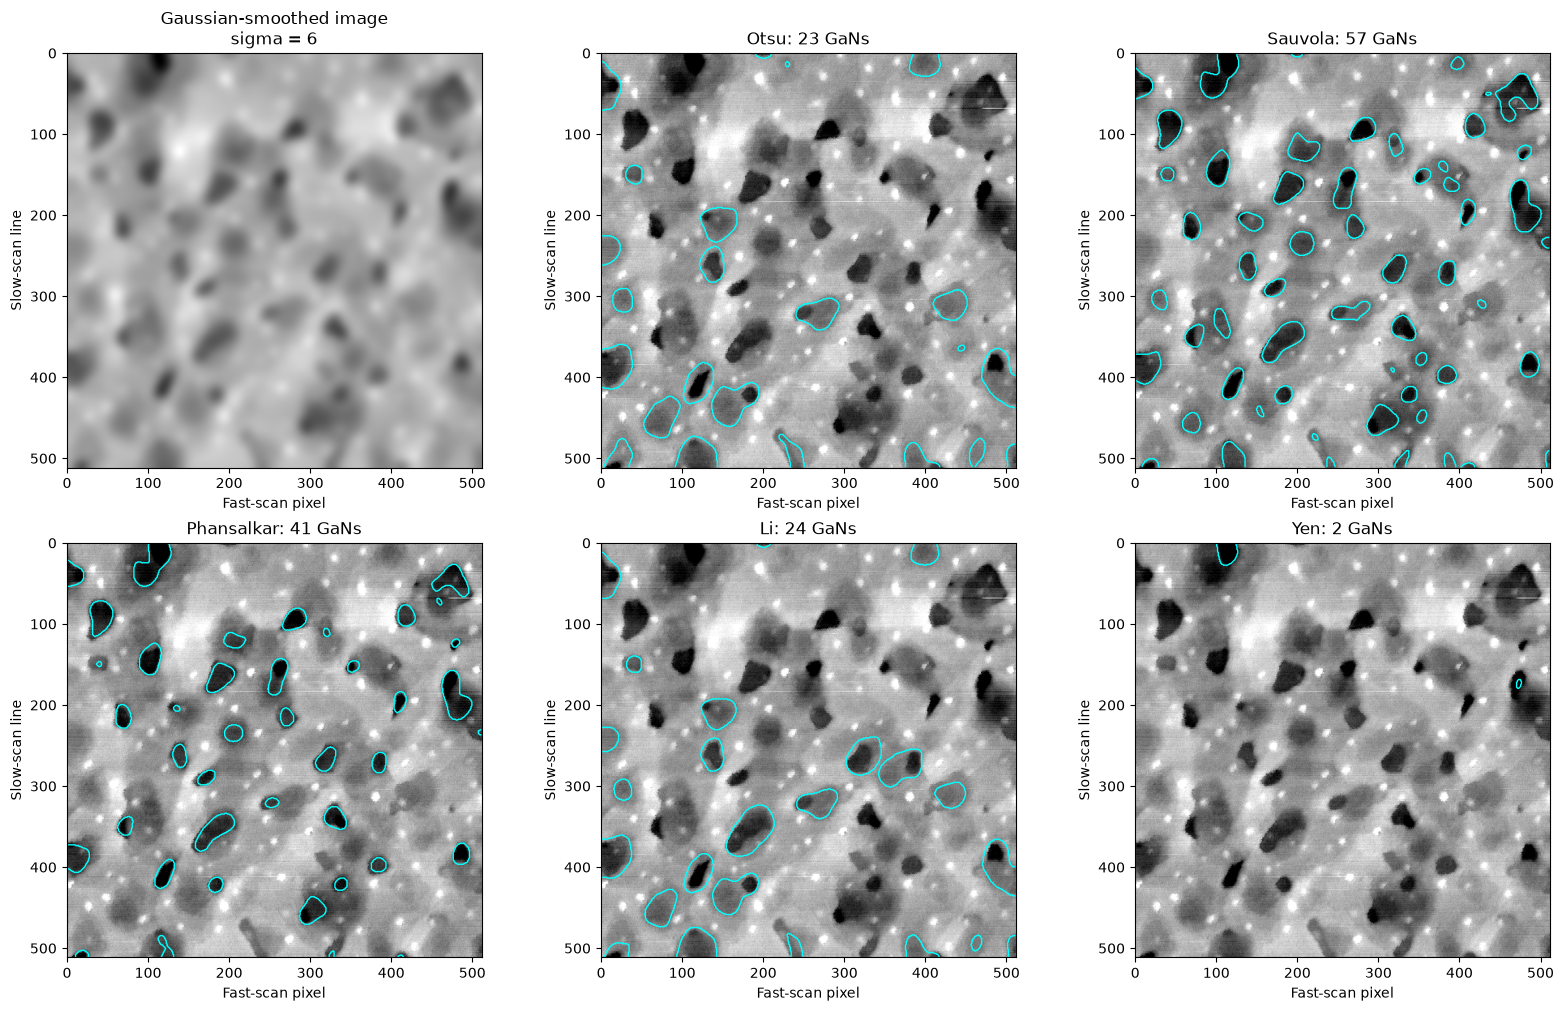

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)

axes[0, 0].imshow(z_GaN_smooth, cmap="gray",)

axes[0, 0].set_title(
    f"Gaussian-smoothed image\n"
    f"sigma = {GaN_sigma}"
)

method_names = ["Otsu", "Sauvola", "Phansalkar", "Li", "Yen",]
display_vmin, display_vmax = np.nanpercentile(z_processed, [1, 99],)

for ax, method_name in zip( axes.ravel()[1:], method_names,):
    current_mask = filtered_masks[method_name]
    current_labels = label(current_mask)

    ax.imshow(z_processed, cmap="gray", vmin=display_vmin, vmax=display_vmax,)
    ax.contour(current_mask, levels=[0.5], colors="cyan", linewidths=1,)
    ax.set_title(
        f"{method_name}: "
        f"{current_labels.max()} GaNs"
    )

for ax in axes.ravel():
    ax.set_xlabel("Fast-scan pixel")
    ax.set_ylabel("Slow-scan line")

plt.show()

## 4. Select the preferred method

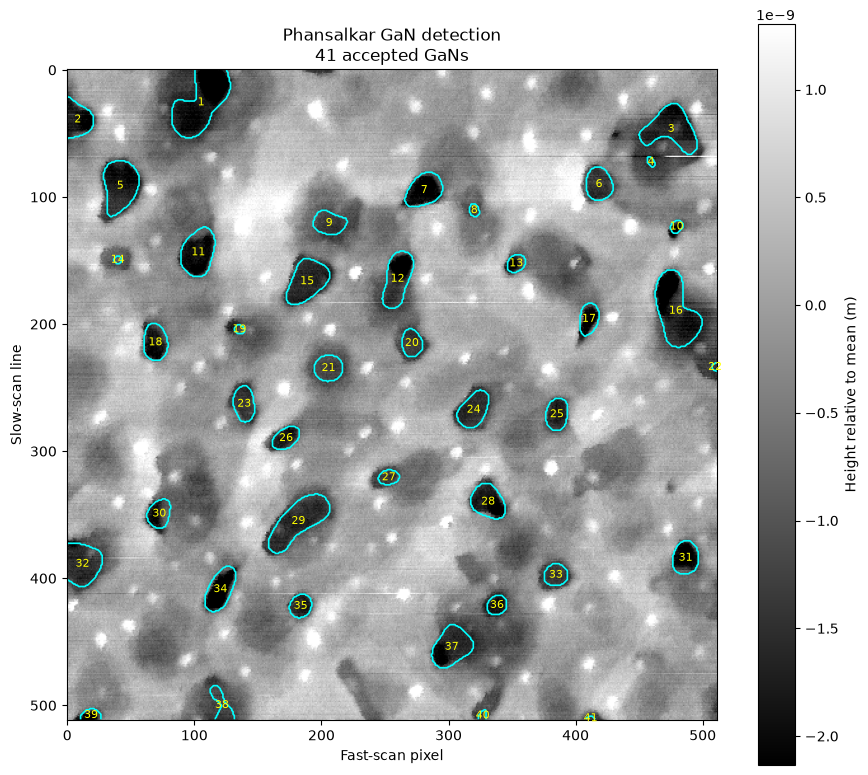

In [13]:
chosen_method = "Phansalkar"
GaN_mask = filtered_masks[chosen_method]
GaN_labels = label(GaN_mask)
GaN_regions = regionprops(GaN_labels)

fig, ax = plt.subplots(figsize=(9, 8))

image_display = ax.imshow(
    z_processed,
    cmap="gray",
    vmin=display_vmin,
    vmax=display_vmax,
)

ax.contour(GaN_mask, levels=[0.5], colors="cyan", linewidths=1.2,)

for region in regionprops(GaN_labels):
    y, x = region.centroid
    ax.text(x, y, str(region.label), color="yellow", fontsize=8, ha="center", va="center",)

ax.set_title(
    f"{chosen_method} GaN detection\n"
    f"{len(GaN_regions)} accepted GaNs"
)

ax.set_xlabel("Fast-scan pixel")
ax.set_ylabel("Slow-scan line")

fig.colorbar(image_display, ax=ax, label="Height relative to mean (m)")

plt.tight_layout()
plt.show()

## 5. Measure GaN height/depth

In [14]:
background_ring_width = 8
measurements = []

for region in regionprops(GaN_labels):

    individual_GaN = (GaN_labels == region.label)
    expanded_GaN = binary_dilation(individual_GaN, footprint=disk(background_ring_width))
    local_background_ring = (expanded_GaN & ~individual_GaN & np.isfinite(z_processed))

    GaN_values = z_processed[individual_GaN]
    background_values = z_processed[local_background_ring]

    if (GaN_values.size == 0 or background_values.size < 10):
        continue

    local_surface = np.nanmedian(background_values)
    minimum_height = np.nanmin(GaN_values)
    median_height = np.nanmedian(GaN_values)
    mean_height = np.nanmean(GaN_values)
    maximum_depth = (local_surface - minimum_height)
    median_depth = (local_surface - median_height)

    mean_depth = (local_surface - mean_height)

    centroid_y, centroid_x = (region.centroid)

    measurements.append(
        {
            "GaN_id": region.label,
            "centroid_y": centroid_y,
            "centroid_x": centroid_x,
            "area_pixels": region.area,
            "equivalent_diameter_pixels":
                region.equivalent_diameter_area,
            "major_axis_pixels":
                region.axis_major_length,
            "minor_axis_pixels":
                region.axis_minor_length,
            "maximum_depth_m":
                maximum_depth,
            "median_depth_m":
                median_depth,
            "mean_depth_m":
                mean_depth,
            "maximum_depth_nm":
                maximum_depth * 1e9,
            "median_depth_nm":
                median_depth * 1e9,
            "mean_depth_nm":
                mean_depth * 1e9,
        }
    )


# 7. Print measurements

print("Threshold method:", chosen_method,)
print("Number of detected GaNs:", len(measurements),)

for GaN in measurements:
    print(f"\nGaN {GaN['GaN_id']}")
    print("  Centroid:", (round(GaN["centroid_y"], 2), round(GaN["centroid_x"], 2),),)
    print("  Area:", GaN["area_pixels"], "pixels",)
    print( "  Equivalent diameter:", round(GaN["equivalent_diameter_pixels"], 2,),"pixels",)
    print("  Maximum depth:", round(GaN["maximum_depth_nm"], 3,), "nm",)
    print("  Median depth:", round(GaN["median_depth_nm"], 3,), "nm",)

/var/folders/mh/m6vpz3p153zc20j8vy1vf3780000gn/T/ipykernel_73567/1661418990.py:7: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  expanded_GaN = binary_dilation(individual_GaN, footprint=disk(background_ring_width))


Threshold method: Phansalkar
Number of detected GaNs: 41

GaN 1
  Centroid: (np.float64(25.66), np.float64(105.36))
  Area: 1456.0 pixels
  Equivalent diameter: 43.06 pixels
  Maximum depth: 2.54 nm
  Median depth: 0.815 nm

GaN 2
  Centroid: (np.float64(39.07), np.float64(8.31))
  Area: 496.0 pixels
  Equivalent diameter: 25.13 pixels
  Maximum depth: 2.295 nm
  Median depth: 1.398 nm

GaN 3
  Centroid: (np.float64(46.53), np.float64(475.26))
  Area: 978.0 pixels
  Equivalent diameter: 35.29 pixels
  Maximum depth: 1.698 nm
  Median depth: 0.744 nm

GaN 4
  Centroid: (np.float64(72.41), np.float64(459.35))
  Area: 34.0 pixels
  Equivalent diameter: 6.58 pixels
  Maximum depth: 0.398 nm
  Median depth: 0.156 nm

GaN 5
  Centroid: (np.float64(91.18), np.float64(41.75))
  Area: 890.0 pixels
  Equivalent diameter: 33.66 pixels
  Maximum depth: 2.052 nm
  Median depth: 1.414 nm

GaN 6
  Centroid: (np.float64(89.93), np.float64(418.44))
  Area: 433.0 pixels
  Equivalent diameter: 23.48 pixe

So, now we have 2 classes of object that code is able to detect. The rest of the analysis of separating and analysing GaN crystal and QD are presented in the analysis file.

# Detecting QDs within and outside the GaN layer

Here the Sauvola thresholding creates the mask, and matplotlib ax.contour sketches the contour.

## 1. Detecting QDs within the GaN layer

In [15]:
from skimage.morphology import binary_erosion

# Bright QDs are holes in the dark GaN mask.
GaN_membership_mask = binary_fill_holes(GaN_mask)
GaN_membership_labels = label(GaN_membership_mask)


# Apply white top-hat filter
tophat_radius = 6 # Choose a radius slightly larger than the typical QD radius.
tophat_map = white_tophat(z_processed, footprint=disk(tophat_radius),)
tophat_map = gaussian_filter(tophat_map, sigma=0.7, mode="reflect",)


# Restrict the top-hat response to GaNs only
tophat_inside_GaNs = np.where(GaN_membership_mask, tophat_map, 0.0,)
inside_values = tophat_inside_GaNs[GaN_membership_mask]
inside_values = inside_values[np.isfinite(inside_values)]
tophat_threshold = np.nanpercentile( inside_values, 85,)


# Detect candidate QDs only inside GaNs

candidate_peaks_inside = peak_local_max(
    tophat_inside_GaNs,
    min_distance=3,
    threshold_abs=tophat_threshold,
    exclude_border=False,
    labels=GaN_membership_mask.astype(
        np.uint8
    ),
)

print( "Top-hat candidates inside GaNs:", len(candidate_peaks_inside),)

Top-hat candidates inside GaNs: 211


In [16]:
GaN_inner_mask = binary_erosion(
    GaN_membership_mask,
    footprint=disk(3),
)

candidate_peaks_inside_no_edge = peak_local_max(
    tophat_inside_GaNs,
    min_distance=3,
    threshold_abs=tophat_threshold,
    exclude_border=False,
    labels=GaN_inner_mask.astype(np.uint8),
)

print( "Top-hat candidates inside GaNs:", len(candidate_peaks_inside_no_edge),)

Top-hat candidates inside GaNs: 134


/var/folders/mh/m6vpz3p153zc20j8vy1vf3780000gn/T/ipykernel_73567/999225182.py:1: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  GaN_inner_mask = binary_erosion(


**Validate each candidate using local dot height**

In [17]:
minimum_dot_height = 6e-10

peak_radius = 1
ring_inner_radius = 3
ring_outer_radius = 7

inside_qd_y = []
inside_qd_x = []
inside_qd_heights = []
inside_qd_GaN_ids = []


for candidate_y, candidate_x in candidate_peaks_inside_no_edge:

    GaN_id = int(GaN_membership_labels[candidate_y, candidate_x,])

    if GaN_id == 0:
        continue

    y0 = max(0, candidate_y - ring_outer_radius,)
    y1 = min(z_processed.shape[0], candidate_y + ring_outer_radius + 1,)

    x0 = max(0, candidate_x - ring_outer_radius,)
    x1 = min(z_processed.shape[1], candidate_x + ring_outer_radius + 1,)

    local_height = z_processed[y0:y1, x0:x1,]
    local_labels = GaN_membership_labels[y0:y1, x0:x1,]

    yy, xx = np.ogrid[y0:y1, x0:x1,]

    rr2 = ((yy - candidate_y) ** 2 + (xx - candidate_x) ** 2)

    peak_mask = (rr2 <= peak_radius**2)
    ring_mask = ((rr2 >= ring_inner_radius**2) & (rr2 <= ring_outer_radius**2))

    same_GaN_ring = ( ring_mask & (local_labels == GaN_id))

    peak_values = local_height[peak_mask]
    background_values = local_height[same_GaN_ring]
    peak_values = peak_values[np.isfinite(peak_values)]

    background_values = background_values[np.isfinite(background_values)]

    if (peak_values.size == 0 or background_values.size < 8):
        continue

    local_peak = np.nanmax(peak_values)
    local_background = np.nanmedian(background_values)
    local_dot_height = (local_peak - local_background)

    if local_dot_height >= minimum_dot_height:
        inside_qd_y.append(candidate_y)
        inside_qd_x.append(candidate_x)
        inside_qd_heights.append(local_dot_height)
        inside_qd_GaN_ids.append(GaN_id)


inside_qd_y = np.asarray(inside_qd_y, dtype=int,)
inside_qd_x = np.asarray(inside_qd_x, dtype=int,)
inside_qd_heights = np.asarray(inside_qd_heights, dtype=float,)
inside_qd_GaN_ids = np.asarray(inside_qd_GaN_ids, dtype=int,)

print("Accepted QDs inside GaNs:", len(inside_qd_y),)

if len(inside_qd_heights) > 0:
    print("Median height:", np.median(inside_qd_heights) * 1e9, "nm",)

Accepted QDs inside GaNs: 16
Median height: 0.8344004171906552 nm


## 2. Plotting Accepted dots on the GaN layer on the original AFM image

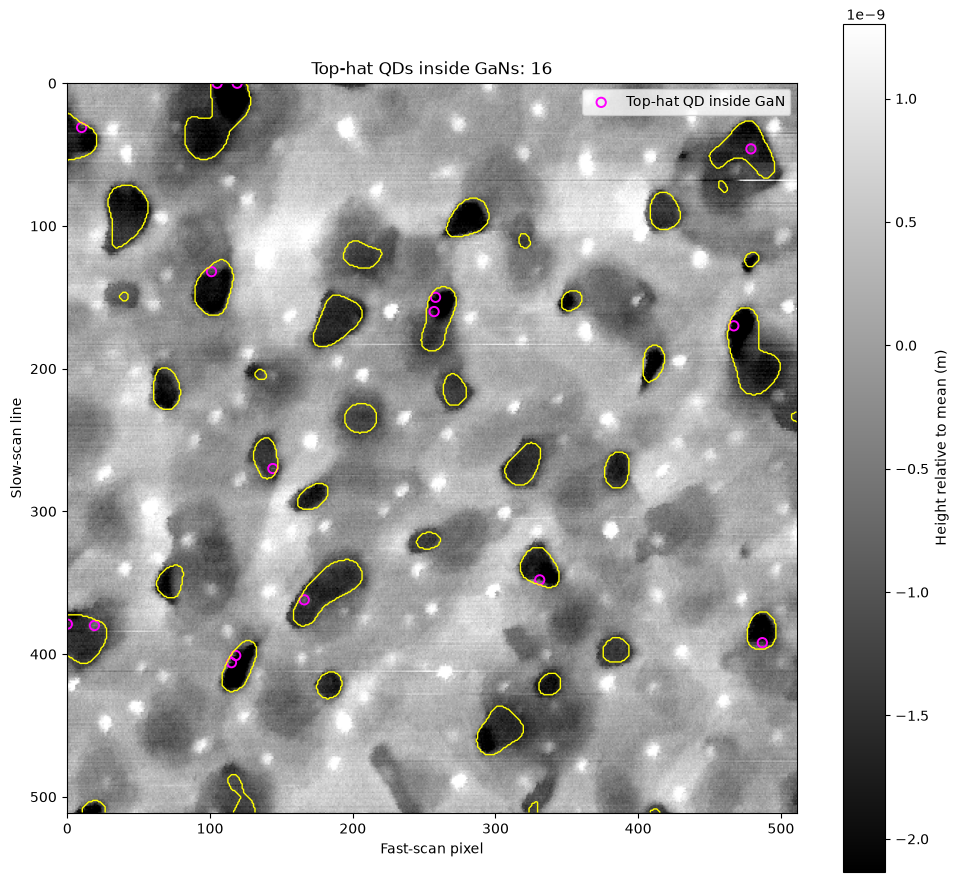

In [18]:
fig, ax = plt.subplots(figsize=(10, 9))

image_display = ax.imshow(
    z_processed,
    cmap="gray",
    vmin=np.nanpercentile( z_processed, 1,),
    vmax=np.nanpercentile( z_processed, 99, ),
)

ax.contour(GaN_mask, levels=[0.5], colors="yellow", linewidths=1.0,) #level 0.5 is the standard contour value used for evaluating the contour along a binary mask 

ax.scatter(
    inside_qd_x,
    inside_qd_y,
    s=45,
    facecolors="none",
    edgecolors="magenta",
    linewidths=1.4,
    label="Top-hat QD inside GaN",
)

ax.set_title(
    f"Top-hat QDs inside GaNs: "
    f"{len(inside_qd_y)}"
)

ax.set_xlabel("Fast-scan pixel")
ax.set_ylabel("Slow-scan line")

fig.colorbar( image_display, ax=ax, label="Height relative to mean (m)",)

ax.legend()
plt.tight_layout()
plt.show()

## 3. Detecting QDs outside of the GaN layer, so these QDs will be on the InGaN layer

Detect top-hat QDs outside GaNs

In [19]:
outside_mask = (~GaN_membership_mask & np.isfinite(z_processed))

tophat_outside_GaNs = np.where(outside_mask, tophat_map, 0.0,)

outside_values = tophat_outside_GaNs[outside_mask]
outside_values = outside_values[np.isfinite(outside_values)]

outside_tophat_threshold = np.nanpercentile(outside_values, 85,)

candidate_peaks_outside = peak_local_max(
    tophat_outside_GaNs,
    min_distance=3,
    threshold_abs=outside_tophat_threshold,
    exclude_border=False,
    labels=outside_mask.astype(np.uint8),
)

print("Top-hat candidates outside GaNs:", len(candidate_peaks_outside),)

Top-hat candidates outside GaNs: 1755


**Validate outside candidates by local height**

In [20]:
minimum_dot_height = 6e-10

peak_radius = 2
ring_inner_radius = 3
ring_outer_radius = 7

outside_qd_y = []
outside_qd_x = []
outside_qd_heights = []


for candidate_y, candidate_x in candidate_peaks_outside:

    # Candidate must remain outside GaNs
    if GaN_membership_mask[candidate_y, candidate_x,]:
        continue

    y0 = max(0, candidate_y - ring_outer_radius,)
    y1 = min(z_processed.shape[0], candidate_y + ring_outer_radius + 1,)

    x0 = max(0, candidate_x - ring_outer_radius,)
    x1 = min(z_processed.shape[1], candidate_x + ring_outer_radius + 1,)

    local_height = z_processed[y0:y1, x0:x1,]
    local_membership = GaN_membership_mask[y0:y1, x0:x1,]

    yy, xx = np.ogrid[y0:y1, x0:x1,]
    rr2 = ((yy - candidate_y) ** 2 + (xx - candidate_x) ** 2)

    peak_mask = (rr2 <= peak_radius**2)

    ring_mask = ((rr2 >= ring_inner_radius**2) & (rr2 <= ring_outer_radius**2))

    # Use only non-GaN pixels for the outside background.
    outside_background_ring = (ring_mask & (~local_membership))

    peak_values = local_height[peak_mask]
    background_values = local_height[outside_background_ring]
    peak_values = peak_values[np.isfinite(peak_values)]
    background_values = background_values[np.isfinite(background_values)]

    if (peak_values.size == 0 or background_values.size < 8):
        continue

    local_peak = np.nanmax(peak_values)
    local_background = np.nanmedian(background_values)
    local_dot_height = (local_peak - local_background)

    if local_dot_height >= minimum_dot_height:
        outside_qd_y.append(candidate_y)
        outside_qd_x.append(candidate_x)
        outside_qd_heights.append(local_dot_height)


outside_qd_y = np.asarray(outside_qd_y, dtype=int,)
outside_qd_x = np.asarray(outside_qd_x, dtype=int,)

outside_qd_heights = np.asarray(outside_qd_heights, dtype=float,)

print("Accepted QDs outside GaNs:", len(outside_qd_y),)

if len(outside_qd_heights) > 0:
    print("Median outside QD height:", np.median(outside_qd_heights) * 1e9,"nm",)

Accepted QDs outside GaNs: 148
Median outside QD height: 0.9206121779284993 nm


## 4. Plot inside QDs in pink and outside QDs in orange

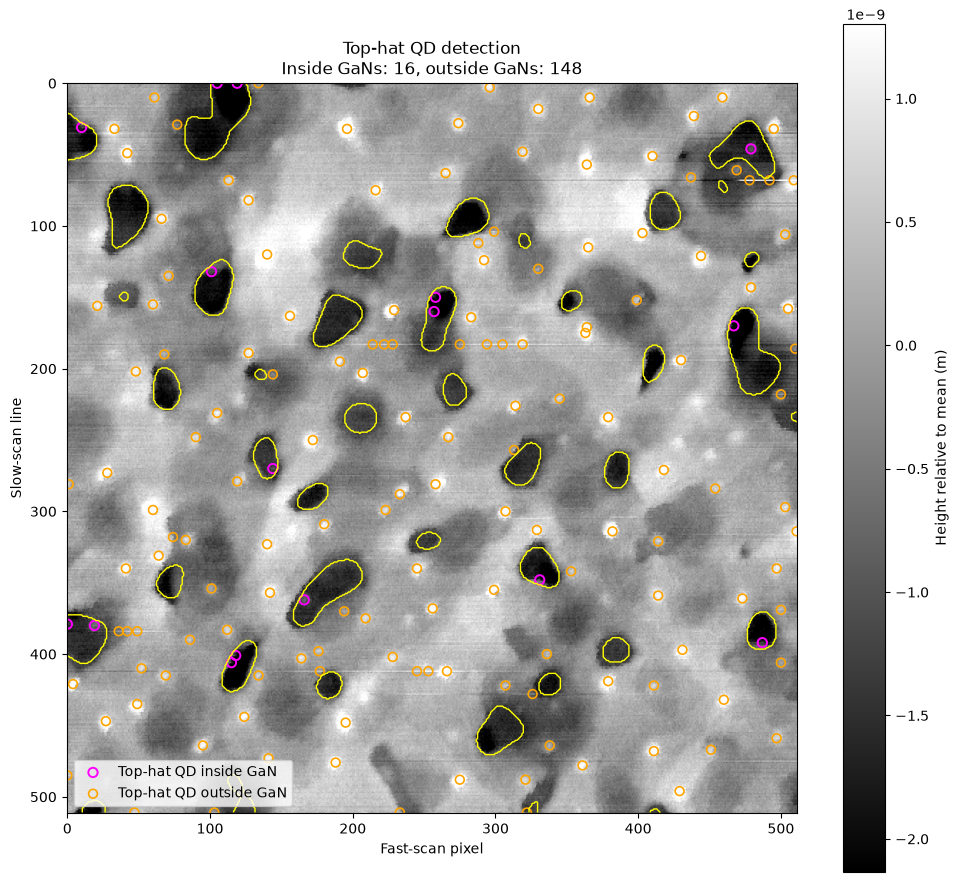

In [21]:
fig, ax = plt.subplots(figsize=(10, 9))

image_display = ax.imshow(
    z_processed,
    cmap="gray",
    vmin=np.nanpercentile( z_processed, 1,),
    vmax=np.nanpercentile( z_processed, 99, ),
)

ax.contour(GaN_mask, levels=[0.5], colors="yellow", linewidths=1.0,)

# Inside-GaN QDs
ax.scatter(
    inside_qd_x,
    inside_qd_y,
    s=45,
    facecolors="none",
    edgecolors="magenta",
    linewidths=1.4,
    label="Top-hat QD inside GaN",
)

# Outside-GaN QDs
ax.scatter(
    outside_qd_x,
    outside_qd_y,
    s=40,
    facecolors="none",
    edgecolors="orange",
    linewidths=1.2,
    label="Top-hat QD outside GaN",
)

ax.set_title(
    f"Top-hat QD detection\n"
    f"Inside GaNs: {len(inside_qd_y)}, "
    f"outside GaNs: {len(outside_qd_y)}"
)

ax.set_xlabel("Fast-scan pixel")
ax.set_ylabel("Slow-scan line")
fig.colorbar( image_display, ax=ax, label="Height relative to mean (m)",)
ax.legend()
plt.tight_layout()
plt.show()

# Comparing and Analysing QDs on GaN and InGaN layers

Now, since we have 2 classes, we can compare if dots on GaN layer and dots on the InGaN layer are morphologically different. 

**To do this, lets compare:**
* local height above surrounding surface
* full width at half maximum in x and y
* equivalent diameter
* area above a relative-height threshold
* aspect ratio
* eccentricity
* circularity
* top-hat response strength
* local GaN depth for inside-GaN dots

In [22]:
import numpy as np
import pandas as pd

from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects

In [23]:
geometry_radius = 8

# Segment each dot at this fraction of its local peak height.
relative_contour_fraction = 0.50
minimum_segment_area = 3

# Combine both QD classes
all_qd_y = np.concatenate([inside_qd_y, outside_qd_y,])
all_qd_x = np.concatenate([inside_qd_x, outside_qd_x,])

all_qd_class = np.concatenate([np.full(len(inside_qd_y), "inside_GaN", dtype=object,), np.full(len(outside_qd_y), "outside_GaN",dtype=object,)])

## 1. Measure the selected properties of each QD

In [24]:
# Measure each QD
qd_features = []

for qd_id, (centre_y, centre_x, qd_class,) in enumerate(
    zip(all_qd_y, all_qd_x, all_qd_class,), start=1,):

    y0 = max(0, centre_y - geometry_radius,)
    y1 = min(z_processed.shape[0], centre_y + geometry_radius + 1,)

    x0 = max(0, centre_x - geometry_radius,)
    x1 = min(z_processed.shape[1], centre_x + geometry_radius + 1,)

    patch = z_processed[y0:y1, x0:x1,]

    yy, xx = np.ogrid[y0:y1, x0:x1,]
    rr2 = ((yy - centre_y) ** 2 + (xx - centre_x) ** 2)

    background_ring = ((rr2 >= 5**2) & (rr2 <= geometry_radius**2))
    background_values = patch[background_ring]
    background_values = background_values[np.isfinite(background_values)]

    if background_values.size < 10:
        continue

    local_background = np.nanmedian(background_values)
    local_patch = (patch - local_background)
    local_peak = np.nanmax(local_patch)

    if (not np.isfinite(local_peak) or local_peak <= 0):
        continue

    contour_level = (relative_contour_fraction * local_peak)

    dot_binary = (local_patch >= contour_level)
    dot_binary = remove_small_objects(dot_binary, min_size=minimum_segment_area,)
    dot_labels = label(dot_binary)

    local_centre_y = (centre_y - y0)
    local_centre_x = (centre_x - x0)
    dot_label_at_centre = dot_labels[local_centre_y, local_centre_x,]

    # If the exact centre is not segmented, use the nearest segmented component to the detected peak.
    if dot_label_at_centre == 0:
        regions = regionprops(dot_labels)
        if len(regions) == 0:
            continue

        distances = []

        for region in regions:
            region_y, region_x = (region.centroid)
            distance = np.hypot(region_y - local_centre_y, region_x - local_centre_x,)
            distances.append(distance)

        selected_region = regions[np.argmin(distances)]

    else:
        selected_region = regionprops(dot_labels)[dot_label_at_centre - 1]


    area_pixels = selected_region.area
    equivalent_diameter = (selected_region.equivalent_diameter_area)
    major_axis = (selected_region.axis_major_length)
    minor_axis = (selected_region.axis_minor_length)
    eccentricity = (selected_region.eccentricity)
    perimeter = (selected_region.perimeter)

    if perimeter > 0:
        circularity = (4 * np.pi * area_pixels / perimeter**2)
    else:
        circularity = np.nan

    if minor_axis > 0:
        aspect_ratio = (major_axis / minor_axis)
    else:
        aspect_ratio = np.nan


    # Estimate FWHM directly from horizontal profile
    horizontal_profile = local_patch[local_centre_y,:]
    vertical_profile = local_patch[:, local_centre_x,]

    half_height = (0.5 * local_peak)

    horizontal_above = np.where(horizontal_profile >= half_height)[0]
    vertical_above = np.where(vertical_profile >= half_height)[0]

    if horizontal_above.size > 0:
        fwhm_x_pixels = (horizontal_above[-1] - horizontal_above[0] + 1)

    else:
        fwhm_x_pixels = np.nan

    if vertical_above.size > 0:
        fwhm_y_pixels = (vertical_above[-1] - vertical_above[0] + 1)

    else:
        fwhm_y_pixels = np.nan


    qd_features.append(
        {
            "qd_id": qd_id,
            "class": qd_class,
            "centre_y": centre_y,
            "centre_x": centre_x,
            "height_m": local_peak,
            "height_nm": local_peak * 1e9,
            "area_pixels": area_pixels,
            "equivalent_diameter_pixels":
                equivalent_diameter,
            "major_axis_pixels":
                major_axis,
            "minor_axis_pixels":
                minor_axis,
            "aspect_ratio":
                aspect_ratio,
            "eccentricity":
                eccentricity,
            "perimeter_pixels":
                perimeter,
            "circularity":
                circularity,
            "fwhm_x_pixels":
                fwhm_x_pixels,
            "fwhm_y_pixels":
                fwhm_y_pixels,
        }
    )

qd_feature_table = pd.DataFrame(qd_features)

print(qd_feature_table.head())
print("\nNumber of measured QDs by class:")
print(qd_feature_table["class"].value_counts())

   qd_id       class  centre_y  centre_x      height_m  height_nm  \
0      1  inside_GaN         0       119  2.621566e-09   2.621566   
1      3  inside_GaN        46       479  8.149951e-10   0.814995   
2      4  inside_GaN       362       166  1.755089e-09   1.755089   
3      5  inside_GaN       380        19  8.771445e-10   0.877145   
4      6  inside_GaN         0       105  1.679209e-09   1.679209   

   area_pixels  equivalent_diameter_pixels  major_axis_pixels  \
0         26.0                    5.753627           9.093660   
1         24.0                    5.527906           7.058532   
2         36.0                    6.770275          11.046253   
3         18.0                    4.787307           6.481796   
4         57.0                    8.519076          10.835066   

   minor_axis_pixels  aspect_ratio  eccentricity  perimeter_pixels  \
0           4.469889      2.034427      0.870856         19.656854   
1           4.732795      1.491409      0.741903      

/var/folders/mh/m6vpz3p153zc20j8vy1vf3780000gn/T/ipykernel_73567/2542962837.py:35: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  dot_binary = remove_small_objects(dot_binary, min_size=minimum_segment_area,)


## 2. Comparing the QD parameters

In [25]:
summary_table = (
    qd_feature_table
    .groupby("class")
    [
        [
            "height_nm",
            "area_pixels",
            "equivalent_diameter_pixels",
            "major_axis_pixels",
            "minor_axis_pixels",
            "aspect_ratio",
            "eccentricity",
            "circularity",
            "fwhm_x_pixels",
            "fwhm_y_pixels",
        ]
    ]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
        ]
    )
)

print(summary_table)

            height_nm                               area_pixels             \
                count      mean    median       std       count       mean   
class                                                                        
inside_GaN         15  1.635248  1.711211  0.653727          15  66.800000   
outside_GaN       147  1.173983  1.083117  0.404212         147  31.455782   

                              equivalent_diameter_pixels            ...  \
            median        std                      count      mean  ...   
class                                                               ...   
inside_GaN    57.0  38.075489                         15  8.836081  ...   
outside_GaN   32.0  16.102510                        147  6.101702  ...   

            circularity           fwhm_x_pixels                             \
                 median       std         count      mean median       std   
class                                                                        

### Height Distributions

Ground-Truth/ Height-HWFM explains how the mean error in the horizontal axis was found

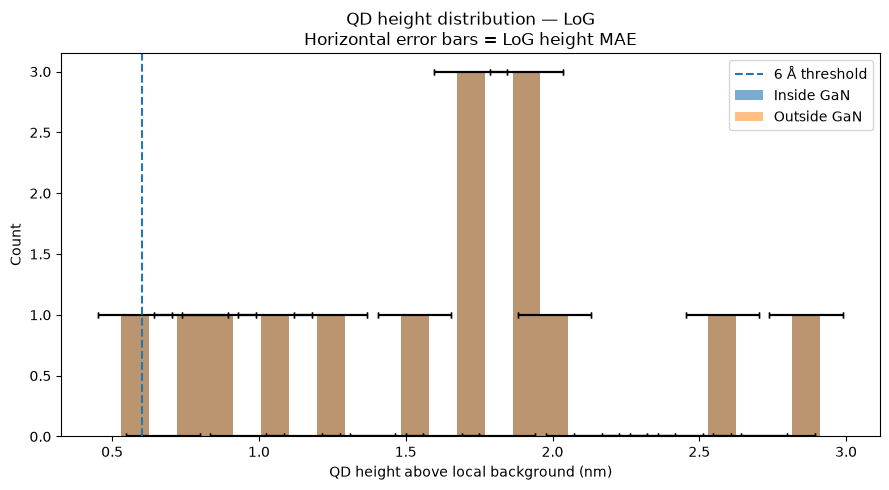

In [26]:
inside_heights = qd_feature_table.loc[qd_feature_table["class"] == "inside_GaN", "height_nm"].to_numpy()
outside_heights = qd_feature_table.loc[qd_feature_table["class"] == "outside_GaN", "height_nm"].to_numpy()

# LoG height MAE
log_height_mae_nm = 0.125   # replace with your actual MAE

# Use the SAME bins for both distributions
all_heights = np.concatenate([inside_heights, outside_heights])
bins = np.linspace(all_heights.min(), all_heights.max(), 26)

inside_counts, edges = np.histogram(inside_heights, bins=bins)
outside_counts, _ = np.histogram(outside_heights, bins=bins)

bin_centres = (edges[:-1] + edges[1:]) / 2
bin_width = np.diff(edges)

fig, ax = plt.subplots(figsize=(9, 5))

# Inside GaN
ax.bar(bin_centres, inside_counts, width=bin_width, alpha=0.6, label="Inside GaN", xerr=log_height_mae_nm, capsize=2)
# Outside GaN
ax.bar(bin_centres, inside_counts, width=bin_width, alpha=0.5, label="Outside GaN", xerr=log_height_mae_nm, capsize=2,)

# 6 Å threshold
ax.axvline(0.6, linestyle="--", linewidth=1.5, label="6 Å threshold",)

ax.set_xlabel("QD height above local background (nm)")
ax.set_ylabel("Count")
ax.set_title("QD height distribution — LoG\nHorizontal error bars = LoG height MAE")

ax.legend()

plt.tight_layout()
plt.show()

But I still neeeded to get the uncertainty in the total QD count.

For Poisson counting statistics **, $$\sigma_{\mathrm{Poisson}} = \sqrt{N}$$, where $N$ is the number of QDs in the histogram bin.

The total uncertainty is therefore $$\sigma_{\mathrm{total}} = \sqrt{\sigma_{\mathrm{height}}^2 + \sigma_{\mathrm{Poisson}}^2} $$ or equivalently, $$ \sigma_{\mathrm{total}} = \sqrt{ \sigma_{\mathrm{height}}^2 + N }.$$

Here, $\sigma_{\mathrm{height}}$ is obtained by propagating the LoG height-measurement uncertainty through the histogram using Monte Carlo sampling.

In [27]:
# For Gaussian errors: MAE = sigma * sqrt(2/pi)
height_sigma_nm = log_height_mae_nm * np.sqrt(np.pi / 2)

In [28]:
# Monte Carlo propagation of height uncertainty
rng = np.random.default_rng(42)
n_trials = 5000

inside_mc_counts = np.zeros((n_trials, len(bin_centres)))
outside_mc_counts = np.zeros((n_trials, len(bin_centres)))

for i in range(n_trials):

    inside_sample = (
        inside_heights
        + rng.normal(
            0,
            height_sigma_nm,
            size=len(inside_heights),
        )
    )

    outside_sample = (outside_heights + rng.normal(0, height_sigma_nm, size=len(outside_heights)))

    inside_mc_counts[i], _ = np.histogram(inside_sample,bins=bins)
    outside_mc_counts[i], _ = np.histogram(outside_sample,bins=bins)

In [29]:
# Height-induced uncertainty in each bin count
inside_height_error = inside_mc_counts.std(axis=0)
outside_height_error = outside_mc_counts.std(axis=0)


# Poisson counting uncertainty
inside_poisson_error = np.sqrt(inside_counts)
outside_poisson_error = np.sqrt(outside_counts)

# Combine uncertainties in quadrature
inside_total_error = np.sqrt(inside_height_error**2 + inside_poisson_error**2)
outside_total_error = np.sqrt(outside_height_error**2 + outside_poisson_error**2)

Plot

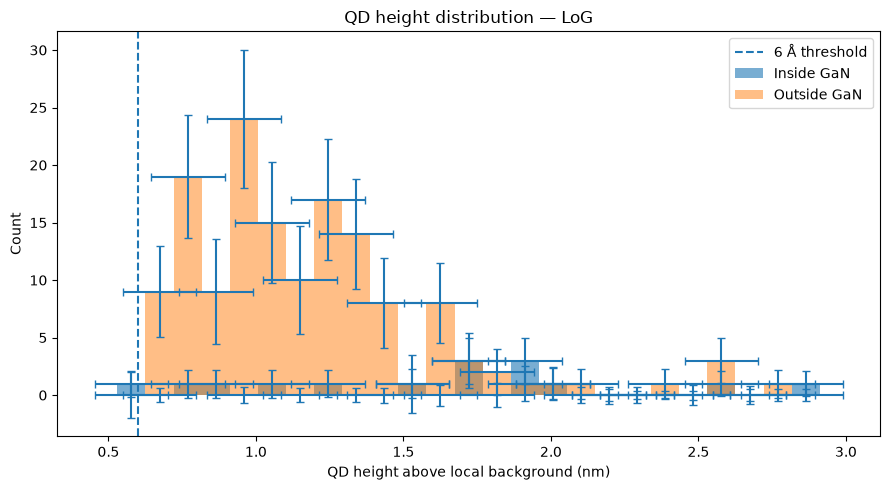

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    bin_centres,
    inside_counts,
    width=bin_width,
    alpha=0.6,
    label="Inside GaN",
)

ax.bar(
    bin_centres,
    outside_counts,
    width=bin_width,
    alpha=0.5,
    label="Outside GaN",
)

# Error bars for Inside GaN
ax.errorbar(
    bin_centres,
    inside_counts,
    xerr=log_height_mae_nm,
    yerr=inside_total_error,
    fmt="none",
    capsize=3,
)

# Error bars for Outside GaN
ax.errorbar(
    bin_centres,
    outside_counts,
    xerr=log_height_mae_nm,
    yerr=outside_total_error,
    fmt="none",
    capsize=3,
)

ax.axvline(
    0.6,
    linestyle="--",
    linewidth=1.5,
    label="6 Å threshold",
)

ax.set_xlabel("QD height above local background (nm)")
ax.set_ylabel("Count")
ax.set_title("QD height distribution — LoG")
ax.legend()

plt.tight_layout()
plt.show()

### Normalising count to get porbability density 

Since this histogram uses `density=True`, the vertical axis represents **probability density** rather than raw counts. For bin $i$, the probability density is $\rho_i = \frac{N_i}{N\,\Delta h_i}$, where $N_i$ is the number of QDs in the bin, $N$ is the total number of QDs, and $\Delta h_i$ is the bin width.

The uncertainty in probability density is therefore $\sigma_{\rho_i} = \frac{\sigma_{N_i}}{N\,\Delta h_i}$. The vertical error bars include both the uncertainty caused by QDs moving between neighbouring bins due to the LoG height-measurement error and ordinary Poisson counting uncertainty, $\sigma_{\mathrm{Poisson}} = \sqrt{N_i}$.

These are combined in quadrature as $\sigma_{N_i,\mathrm{total}} = \sqrt{\sigma_{N_i,\mathrm{height}}^2 + \sigma_{N_i,\mathrm{Poisson}}^2}$, giving the final density uncertainty $\sigma_{\rho_i,\mathrm{total}} = \frac{\sigma_{N_i,\mathrm{total}}}{N\,\Delta h_i}$.

The horizontal error bars represent the uncertainty in the measured QD height from the LoG height MAE.

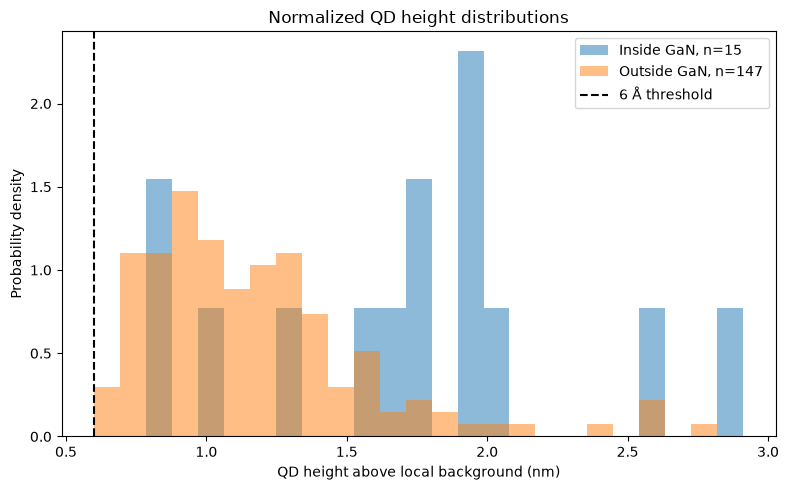

Minimum height in table: 0.5304567494372899 nm
Dots below 0.6 nm: 1


In [31]:
inside_heights_nm = qd_feature_table.loc[qd_feature_table["class"] == "inside_GaN", "height_nm"]
outside_heights_nm = qd_feature_table.loc[qd_feature_table["class"] == "outside_GaN", "height_nm"]

fig, ax = plt.subplots(figsize=(8, 5))

common_bins = np.linspace(0.6, max(inside_heights_nm.max(), outside_heights_nm.max(),), 26)

ax.hist(
    inside_heights_nm,
    bins=common_bins,
    density=True,
    alpha=0.5,
    label=f"Inside GaN, n={len(inside_heights_nm)}",
)

ax.hist(
    outside_heights_nm,
    bins=common_bins,
    density=True,
    alpha=0.5,
    label=f"Outside GaN, n={len(outside_heights_nm)}",
)

ax.axvline(
    0.6,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="6 Å threshold",
)

ax.set_xlabel("QD height above local background (nm)")
ax.set_ylabel("Probability density")
ax.set_title("Normalized QD height distributions")
ax.legend()
plt.tight_layout()
plt.show()

print("Minimum height in table:", qd_feature_table["height_nm"].min(), "nm")
print("Dots below 0.6 nm:", np.sum(qd_feature_table["height_nm"] < 0.6),)

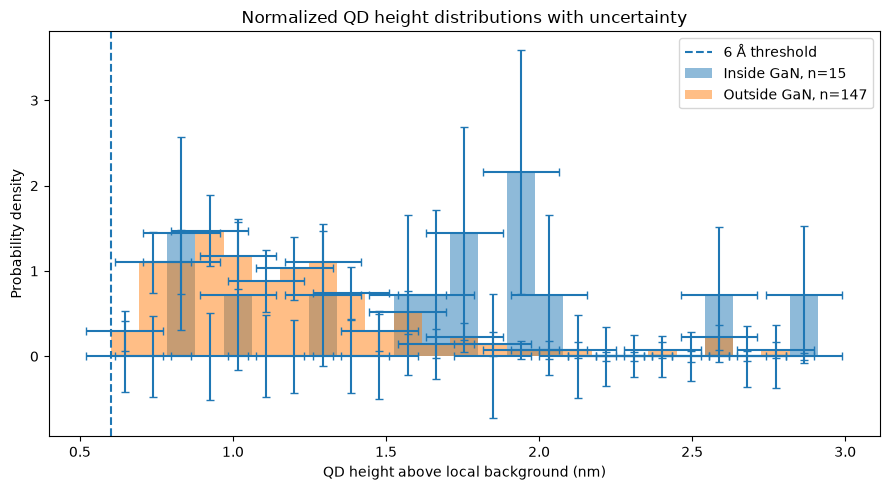

Minimum height in table: 0.5304567494372899 nm
Dots below 0.6 nm: 1


In [32]:
inside_heights_nm = qd_feature_table.loc[qd_feature_table["class"] == "inside_GaN", "height_nm"].dropna().to_numpy()
outside_heights_nm = qd_feature_table.loc[qd_feature_table["class"] == "outside_GaN", "height_nm"].dropna().to_numpy()

height_sigma_nm = log_height_mae_nm * np.sqrt(np.pi / 2)

common_bins = np.linspace(0.6, max(inside_heights_nm.max(), outside_heights_nm.max()), 26)
bin_centres = (common_bins[:-1] + common_bins[1:]) / 2
bin_widths = np.diff(common_bins)

inside_counts, _ = np.histogram(inside_heights_nm, bins=common_bins)
outside_counts, _ = np.histogram(outside_heights_nm, bins=common_bins)

inside_density = inside_counts / (len(inside_heights_nm) * bin_widths)
outside_density = outside_counts / (len(outside_heights_nm) * bin_widths)

rng = np.random.default_rng(42)
n_trials = 5000

inside_mc_counts = np.zeros((n_trials, len(bin_centres)))
outside_mc_counts = np.zeros((n_trials, len(bin_centres)))

for i in range(n_trials):
    inside_sample = inside_heights_nm + rng.normal(0, height_sigma_nm, size=len(inside_heights_nm))
    outside_sample = outside_heights_nm + rng.normal(0, height_sigma_nm, size=len(outside_heights_nm))

    inside_mc_counts[i], _ = np.histogram(inside_sample, bins=common_bins)
    outside_mc_counts[i], _ = np.histogram(outside_sample, bins=common_bins)

inside_height_count_error = inside_mc_counts.std(axis=0)
outside_height_count_error = outside_mc_counts.std(axis=0)

inside_poisson_error = np.sqrt(inside_counts)
outside_poisson_error = np.sqrt(outside_counts)

inside_total_count_error = np.sqrt(inside_height_count_error**2 + inside_poisson_error**2)
outside_total_count_error = np.sqrt(outside_height_count_error**2 + outside_poisson_error**2)

inside_density_error = inside_total_count_error / (len(inside_heights_nm) * bin_widths)
outside_density_error = outside_total_count_error / (len(outside_heights_nm) * bin_widths)

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(bin_centres, inside_density, width=bin_widths, alpha=0.5, label=f"Inside GaN, n={len(inside_heights_nm)}")
ax.bar(bin_centres, outside_density, width=bin_widths, alpha=0.5, label=f"Outside GaN, n={len(outside_heights_nm)}")

ax.errorbar(bin_centres, inside_density, xerr=log_height_mae_nm, yerr=inside_density_error, fmt="none", capsize=3)
ax.errorbar(bin_centres, outside_density, xerr=log_height_mae_nm, yerr=outside_density_error, fmt="none", capsize=3)

ax.axvline(0.6, linestyle="--", linewidth=1.5, label="6 Å threshold")

ax.set_xlabel("QD height above local background (nm)")
ax.set_ylabel("Probability density")
ax.set_title("Normalized QD height distributions with uncertainty")
ax.legend()

plt.tight_layout()
plt.show()

print("Minimum height in table:", qd_feature_table["height_nm"].min(), "nm")
print("Dots below 0.6 nm:", np.sum(qd_feature_table["height_nm"] < 0.6))

But I think I'm doing something wrong here...

### Width distribution

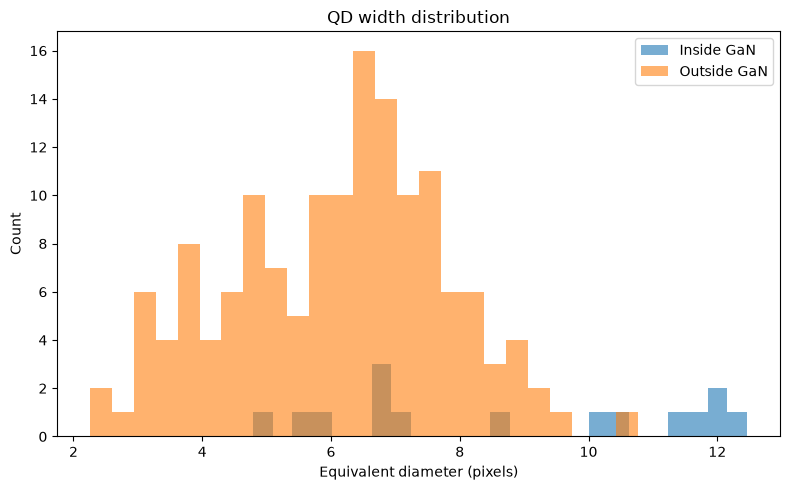

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    qd_feature_table.loc[
        qd_feature_table["class"] == "inside_GaN", "equivalent_diameter_pixels"],
        bins=25,
        alpha=0.6,
        label="Inside GaN",
    )

ax.hist(
    qd_feature_table.loc[
        qd_feature_table["class"] == "outside_GaN", "equivalent_diameter_pixels",
    ],
    bins=25,
    alpha=0.6,
    label="Outside GaN",
)

ax.set_xlabel("Equivalent diameter (pixels)")
ax.set_ylabel("Count")
ax.set_title("QD width distribution")
ax.legend()

plt.tight_layout()
plt.show()

Adding errors

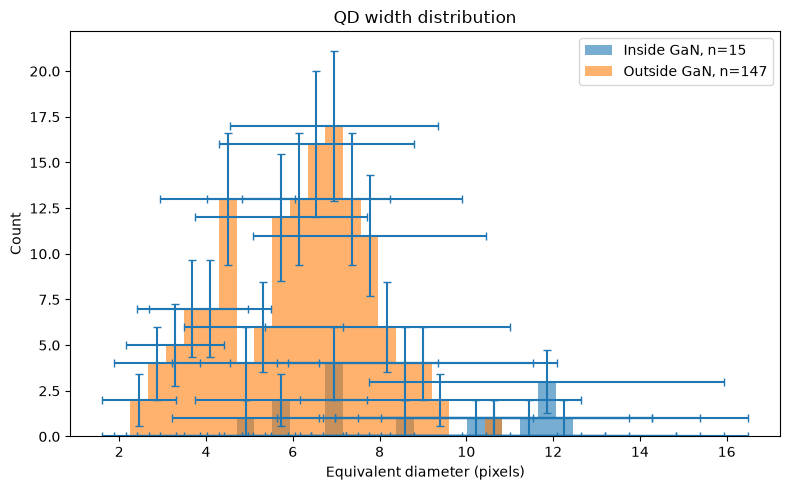

In [34]:
inside_widths = qd_feature_table.loc[qd_feature_table["class"] == "inside_GaN", "equivalent_diameter_pixels"].dropna().to_numpy()
outside_widths = qd_feature_table.loc[qd_feature_table["class"] == "outside_GaN", "equivalent_diameter_pixels"].dropna().to_numpy()

fwhm_relative_error = 0.3447  # 34.47% mean relative FWHM error from ordinary QDs in error table in the Ground truth folder, Height-... folder

common_bins = np.linspace(min(inside_widths.min(), outside_widths.min()), max(inside_widths.max(), outside_widths.max()), 26)
bin_centres = (common_bins[:-1] + common_bins[1:]) / 2
bin_widths = np.diff(common_bins)

inside_counts, _ = np.histogram(inside_widths, bins=common_bins)
outside_counts, _ = np.histogram(outside_widths, bins=common_bins)

inside_xerr = bin_centres * fwhm_relative_error
outside_xerr = bin_centres * fwhm_relative_error

inside_yerr = np.sqrt(inside_counts)
outside_yerr = np.sqrt(outside_counts)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(bin_centres, inside_counts, width=bin_widths, alpha=0.6, label=f"Inside GaN, n={len(inside_widths)}")
ax.bar(bin_centres, outside_counts, width=bin_widths, alpha=0.6, label=f"Outside GaN, n={len(outside_widths)}")

ax.errorbar(bin_centres, inside_counts, xerr=inside_xerr, yerr=inside_yerr, fmt="none", capsize=3)
ax.errorbar(bin_centres, outside_counts, xerr=outside_xerr, yerr=outside_yerr, fmt="none", capsize=3)

ax.set_xlabel("Equivalent diameter (pixels)")
ax.set_ylabel("Count")
ax.set_title("QD width distribution")
ax.legend()

plt.tight_layout()
plt.show()

### Height vs. Width

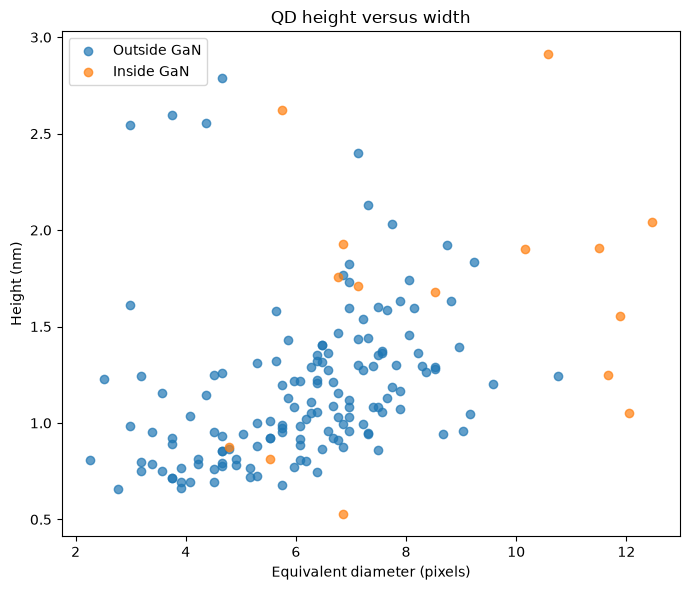

In [35]:
fig, ax = plt.subplots(figsize=(7, 6))

inside_rows = (qd_feature_table["class"] == "inside_GaN")
outside_rows = (qd_feature_table["class"] == "outside_GaN")

ax.scatter(
    qd_feature_table.loc[outside_rows, "equivalent_diameter_pixels",],
    qd_feature_table.loc[outside_rows, "height_nm",],
    alpha=0.7,
    label="Outside GaN",
)

ax.scatter(
    qd_feature_table.loc[inside_rows, "equivalent_diameter_pixels",],
    qd_feature_table.loc[inside_rows, "height_nm",],
    alpha=0.7,
    label="Inside GaN",
)

ax.set_xlabel("Equivalent diameter (pixels)")
ax.set_ylabel("Height (nm)")
ax.set_title("QD height versus width")
ax.legend()

plt.tight_layout()
plt.show()

For the FWHM/width measurements, the error comparison gives a mean absolute FWHM error of **41.54 Å**, an RMSE of **52.22 Å**, a mean relative FWHM error of **41.56%**, and a median relative FWHM error of **38.27%**.

The largest features in the table behave as outliers. Considering the first 59 ordinary-sized QDs instead gives a width MAE of **32.78 Å** and a mean relative FWHM error of **34.47%**, which is more representative of the uncertainty for the majority of detected QDs.

Since the width distributions are plotted using equivalent diameter in pixels, while the error table reports FWHM error in Å, the relative FWHM error can be used as an approximate horizontal uncertainty. The width uncertainty is therefore taken as $\sigma_w \approx 0.3447\,w$, where $w$ is the measured equivalent diameter in pixels.

The horizontal error bars therefore represent the estimated width-measurement uncertainty, while the vertical error bars represent Poisson counting uncertainty, $\sigma_N = \sqrt{N}$.

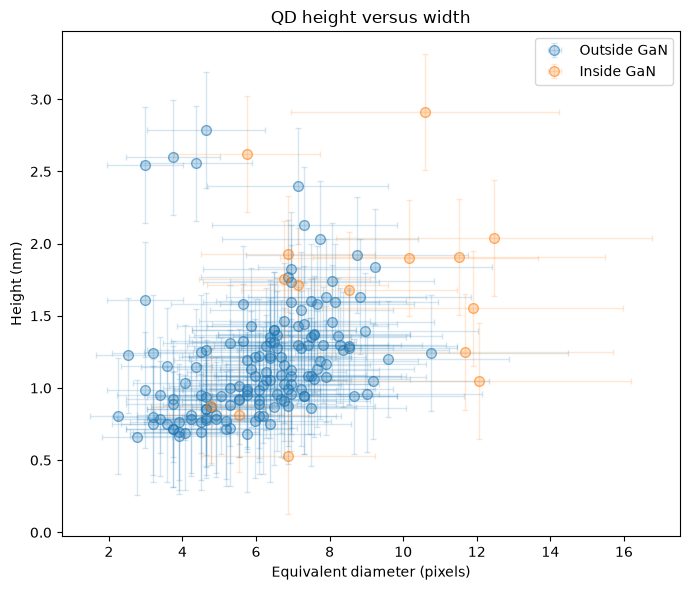

In [36]:
from matplotlib.colors import to_rgba

fig, ax = plt.subplots(figsize=(7, 6))

inside_rows = qd_feature_table["class"] == "inside_GaN"
outside_rows = qd_feature_table["class"] == "outside_GaN"

height_mae_nm = 0.40
fwhm_relative_error = 0.3447

outside_width = qd_feature_table.loc[outside_rows, "equivalent_diameter_pixels"].to_numpy()
outside_height = qd_feature_table.loc[outside_rows, "height_nm"].to_numpy()

inside_width = qd_feature_table.loc[inside_rows, "equivalent_diameter_pixels"].to_numpy()
inside_height = qd_feature_table.loc[inside_rows, "height_nm"].to_numpy()

outside_xerr = fwhm_relative_error * outside_width
inside_xerr = fwhm_relative_error * inside_width

outside_yerr = np.full(len(outside_height), height_mae_nm)
inside_yerr = np.full(len(inside_height), height_mae_nm)

outside_color = "tab:blue"
inside_color = "tab:orange"

ax.errorbar(outside_width, 
            outside_height, 
            xerr=outside_xerr, 
            yerr=outside_yerr, 
            fmt="o", 
            ms=7, 
            mfc=to_rgba(outside_color, 0.25), 
            mec=to_rgba(outside_color, 0.6), 
            ecolor=to_rgba(outside_color, 0.18), 
            elinewidth=1, 
            capsize=2, 
            label="Outside GaN"
        )

ax.errorbar(inside_width, 
            inside_height, 
            xerr=inside_xerr, 
            yerr=inside_yerr, 
            fmt="o", 
            ms=7, 
            mfc=to_rgba(inside_color, 0.25), 
            mec=to_rgba(inside_color, 0.6), 
            ecolor=to_rgba(inside_color, 0.18), 
            elinewidth=1, 
            capsize=2, 
            label="Inside GaN"
        )

ax.set_xlabel("Equivalent diameter (pixels)")
ax.set_ylabel("Height (nm)")
ax.set_title("QD height versus width")
ax.legend()

plt.tight_layout()
plt.show()